# Experiment 2: Pluralistic Methods Under Deployment-Dependent Utility

Compare three alignment conditions across a prevalence-sensitivity sweep (λ):

1. **Standard RLHF** — pooled Bradley-Terry reward model + KL-regularized policy optimization
2. **VPL (inferred)** — group-conditioned RMs with EM-inferred group membership
3. **VPL (oracle)** — group-conditioned RMs with oracle group labels at training time

**Predicted behavior:** at λ=0 all methods preserve Group B utility; as λ increases, utility retention declines for all methods. Oracle VPL should generally outperform inferred VPL, which should outperform standard RLHF, but all should show substantial performative gap.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.environment import EnvironmentConfig, PreferenceEnvironment
from src.experiment2 import (
    Experiment2Config,
    METHODS,
    run_experiment2,
    run_experiment2_multiseed,
)

RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

METHOD_LABELS = {
    "rlhf": "Standard RLHF",
    "vpl_inferred": "VPL (inferred)",
    "vpl_oracle": "VPL (oracle)",
}
METHOD_COLORS = {
    "rlhf": "tab:blue",
    "vpl_inferred": "tab:orange",
    "vpl_oracle": "tab:green",
}

config = Experiment2Config(
    env=EnvironmentConfig(seed=42),
    seed=42,
)
print("Config ready.")

Config ready.


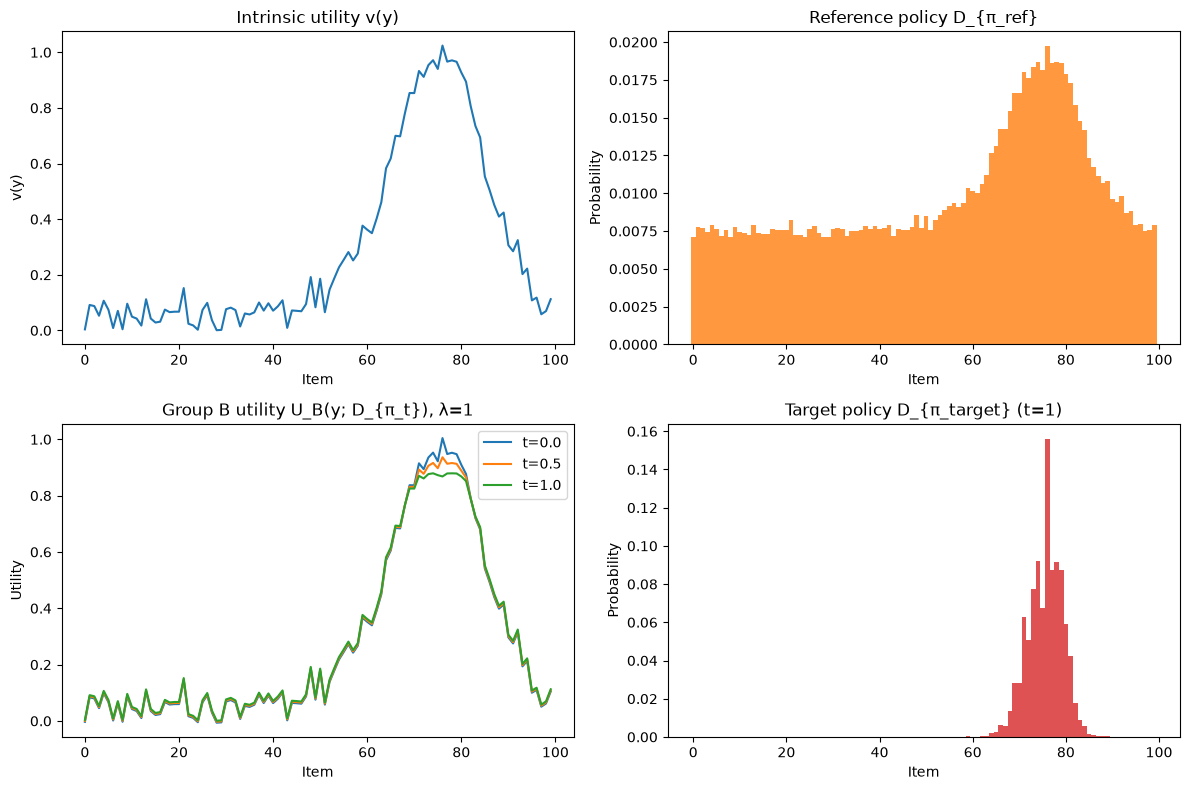

In [2]:
env = PreferenceEnvironment.create(config.env)
items = np.arange(env.n_items)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(items, env.v, color="tab:blue")
axes[0, 0].set_title("Intrinsic utility v(y)")
axes[0, 0].set_xlabel("Item")
axes[0, 0].set_ylabel("v(y)")

axes[0, 1].bar(items, env.pi_ref, width=1.0, color="tab:orange", alpha=0.8)
axes[0, 1].set_title("Reference policy D_{π_ref}")
axes[0, 1].set_xlabel("Item")
axes[0, 1].set_ylabel("Probability")

for t in [0.0, 0.5, 1.0]:
    pi_t = env.policy_at_t(t)
    u_b = env.utility_b(pi_t, lam=1.0)
    axes[1, 0].plot(items, u_b, label=f"t={t}")
axes[1, 0].set_title("Group B utility U_B(y; D_{π_t}), λ=1")
axes[1, 0].set_xlabel("Item")
axes[1, 0].set_ylabel("Utility")
axes[1, 0].legend()

axes[1, 1].bar(items, env.policy_at_t(1.0), width=1.0, color="tab:red", alpha=0.8)
axes[1, 1].set_title("Target policy D_{π_target} (t=1)")
axes[1, 1].set_xlabel("Item")
axes[1, 1].set_ylabel("Probability")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp2_environment.png", dpi=150)
plt.show()

In [3]:
result = run_experiment2(config)
df = result.results

print(f"Sweep rows: {len(df)}")
pivot = df.pivot(index="lambda", columns="method", values="utility_retention")
print("\nUtility retention:")
print(pivot.to_string(float_format=lambda x: f"{x:.4f}"))
df.head(9)


lambda sweep:   0%|          | 0/5 [00:00<?, ?it/s]


lambda sweep:  20%|██        | 1/5 [00:06<00:27,  6.86s/it]


lambda sweep:  40%|████      | 2/5 [00:13<00:20,  6.92s/it]


lambda sweep:  60%|██████    | 3/5 [00:20<00:14,  7.03s/it]


lambda sweep:  80%|████████  | 4/5 [00:28<00:07,  7.15s/it]


lambda sweep: 100%|██████████| 5/5 [00:35<00:00,  7.10s/it]


lambda sweep: 100%|██████████| 5/5 [00:35<00:00,  7.06s/it]

Sweep rows: 15

Utility retention:
method    rlhf  vpl_inferred  vpl_oracle
lambda                                  
0.0     1.0000        0.9927      1.0000
0.5     0.5809        0.5750      0.5994
1.0     0.0279        0.2939      0.0763
2.0    -1.1979       -1.5060     -1.0154
5.0    -6.2432       -3.9499     -5.7029


,lambda,method,utility_retention,subgroup_divergence_pre,subgroup_divergence_post,optimal_utility_b
0,0.0,rlhf,1.000000,0.000000e+00,0.000000,1.024147
1,0.0,vpl_inferred,0.992684,0.000000e+00,0.000000,1.024147
2,0.0,vpl_oracle,1.000000,0.000000e+00,0.000000,1.024147
3,0.5,rlhf,0.580943,5.887279e-07,0.000470,0.911558
4,0.5,vpl_inferred,0.575002,5.887279e-07,0.000474,0.911558
5,0.5,vpl_oracle,0.599382,5.887279e-07,0.000454,0.911558
6,1.0,rlhf,0.027888,2.353215e-06,0.001488,0.866152
7,1.0,vpl_inferred,0.293890,2.353215e-06,0.000754,0.866152
8,1.0,vpl_oracle,0.076305,2.353215e-06,0.001438,0.866152


In [4]:
# Multi-seed robustness (Section 4.6): vary both the environment landscape
# and preference sampling across seeds, report mean +/- std.
N_SEEDS = 10
multi = run_experiment2_multiseed(config, n_seeds=N_SEEDS)
df_ms = multi.per_seed
summary = multi.summary

print(f"Seeds: {multi.seeds}")
print(f"Per-seed rows: {len(df_ms)} | summary rows: {len(summary)}\n")

# Mean +/- std utility retention, pivoted lambda x method.
mean_pivot = summary.pivot(index="lambda", columns="method", values="retention_mean")
std_pivot = summary.pivot(index="lambda", columns="method", values="retention_std")
mean_pivot = mean_pivot[list(METHODS)]
std_pivot = std_pivot[list(METHODS)]

table = mean_pivot.copy().astype(object)
for lam in mean_pivot.index:
    for method in METHODS:
        m = mean_pivot.loc[lam, method]
        s = std_pivot.loc[lam, method]
        table.loc[lam, method] = f"{m:+.3f} +/- {s:.3f}"
table.columns = [METHOD_LABELS[m] for m in table.columns]

print("Utility retention (mean +/- std across seeds):")
print(table.to_string())


seed sweep:   0%|          | 0/10 [00:00<?, ?it/s]


lambda sweep:   0%|          | 0/5 [00:00<?, ?it/s]


lambda sweep:  20%|██        | 1/5 [00:06<00:26,  6.73s/it]


lambda sweep:  40%|████      | 2/5 [00:13<00:20,  6.81s/it]


lambda sweep:  60%|██████    | 3/5 [00:20<00:13,  6.97s/it]

...


lambda sweep: 100%|██████████| 5/5 [00:38<00:00,  7.58s/it]


lambda sweep: 100%|██████████| 5/5 [00:38<00:00,  7.72s/it]



seed sweep: 100%|██████████| 10/10 [06:15<00:00, 38.56s/it]


seed sweep: 100%|██████████| 10/10 [06:15<00:00, 37.57s/it]

Seeds: (42, 43, 44, 45, 46, 47, 48, 49, 50, 51)
Per-seed rows: 150 | summary rows: 15

Utility retention (mean +/- std across seeds):
           Standard RLHF    VPL (inferred)      VPL (oracle)
lambda                                                      
0.0     +0.992 +/- 0.014  +0.977 +/- 0.048  +0.989 +/- 0.014
0.5     +0.713 +/- 0.131  +0.623 +/- 0.067  +0.738 +/- 0.137
1.0     +0.389 +/- 0.363  +0.152 +/- 0.161  +0.460 +/- 0.323
2.0     -0.376 +/- 0.776  -0.904 +/- 0.461  -0.150 +/- 0.667
5.0     -3.298 +/- 2.267  -4.221 +/- 1.398  -2.656 +/- 2.029


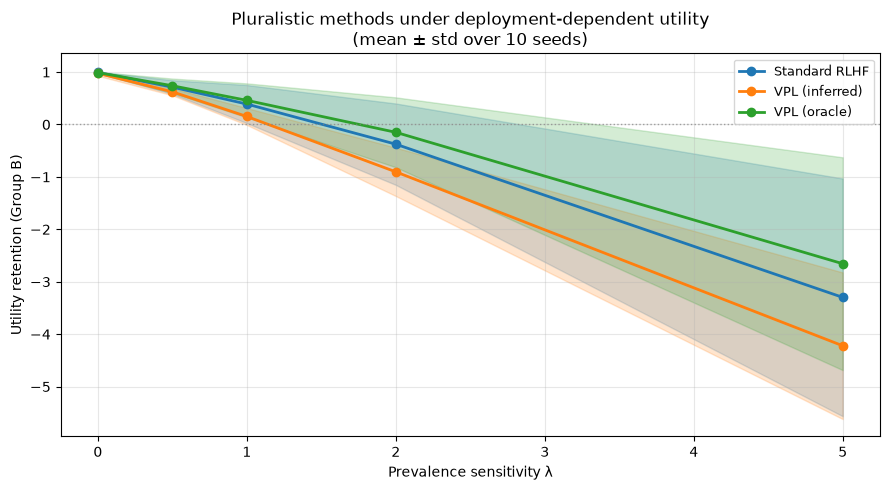

In [5]:
# Headline figure (Section 4.5): mean utility retention vs. lambda with
# +/- std robustness bands across seeds for each method.
fig, ax = plt.subplots(figsize=(9, 5))

for method in METHODS:
    sub = summary[summary["method"] == method].sort_values("lambda")
    lam = sub["lambda"].to_numpy()
    mean = sub["retention_mean"].to_numpy()
    std = sub["retention_std"].to_numpy()
    ax.plot(
        lam,
        mean,
        marker="o",
        linewidth=2,
        color=METHOD_COLORS[method],
        label=METHOD_LABELS[method],
    )
    ax.fill_between(
        lam,
        mean - std,
        mean + std,
        color=METHOD_COLORS[method],
        alpha=0.2,
    )

ax.axhline(0.0, color="gray", linestyle=":", linewidth=1, alpha=0.7)
ax.set_xlabel("Prevalence sensitivity λ")
ax.set_ylabel("Utility retention (Group B)")
ax.set_title(
    f"Pluralistic methods under deployment-dependent utility\n"
    f"(mean ± std over {N_SEEDS} seeds)"
)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp2_headline.png", dpi=150)
plt.show()

In [6]:
# Sanity checks
lam0 = df[df["lambda"] == 0.0]
print("λ=0 utility retention (expect ≈ 1.0):")
print(lam0[["method", "utility_retention"]].to_string(index=False))

pos = df[df["lambda"] > 0]
mean_ret = pos.groupby("method")["utility_retention"].mean().sort_values(ascending=False)
print("\nMean retention at λ>0:")
print(mean_ret.to_string(float_format=lambda x: f"{x:.4f}"))

for method in METHODS:
    sub = df[df["method"] == method].sort_values("lambda")
    ret = sub["utility_retention"].values
    declines = sum(ret[i] > ret[i + 1] + 0.05 for i in range(len(ret) - 1))
    print(f"{METHOD_LABELS[method]}: retention declines {declines}/{len(ret)-1} λ steps (with 0.05 tol)")

# Multi-seed negative control: λ=0 should sit at retention ≈ 1.0 for all methods.
lam0_ms = summary[summary["lambda"] == 0.0]
print("\nλ=0 multi-seed retention (expect ≈ 1.0):")
print(
    lam0_ms[["method", "retention_mean", "retention_std"]].to_string(
        index=False, float_format=lambda x: f"{x:.4f}"
    )
)

df.to_csv(RESULTS_DIR / "exp2_results.csv", index=False)
df_ms.to_csv(RESULTS_DIR / "exp2_results_multiseed.csv", index=False)
summary.to_csv(RESULTS_DIR / "exp2_summary.csv", index=False)
print(f"\nSaved results to {RESULTS_DIR.relative_to(ROOT)}")

λ=0 utility retention (expect ≈ 1.0):
      method  utility_retention
        rlhf           1.000000
vpl_inferred           0.992684
  vpl_oracle           1.000000

Mean retention at λ>0:
method
vpl_inferred   -1.1467
vpl_oracle     -1.5106
rlhf           -1.7081
Standard RLHF: retention declines 4/4 λ steps (with 0.05 tol)
VPL (inferred): retention declines 4/4 λ steps (with 0.05 tol)
VPL (oracle): retention declines 4/4 λ steps (with 0.05 tol)

λ=0 multi-seed retention (expect ≈ 1.0):
      method  retention_mean  retention_std
        rlhf          0.9915         0.0143
vpl_inferred          0.9766         0.0478
  vpl_oracle          0.9890         0.0137

Saved results to results
